#  Weekend Data Challenge #02 — When Does This Business Actually Make Its Money?

##  Superstore Sales Trends, Seasonality & Growth Analysis

This analysis explores the Superstore dataset to understand how sales change over time, identify seasonal patterns, compare year-over-year growth, and investigate an unusual-looking month.


**Tools:** Python, Pandas, Matplotlib  
**Dataset:** Superstore Dataset

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv('Sample - Superstore.csv', encoding = 'latin-1')

In [3]:
df.shape

(9994, 21)

In [4]:
df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,3,CA-2016-138688,6/12/2016,6/16/2016,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,4,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,5,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164


## Data Preparation

In [5]:
df['Order Date'] = pd.to_datetime(df['Order Date'])

In [6]:
df['Year'] = df['Order Date'].dt.year
df['Month'] = df['Order Date'].dt.month


##  2. Monthly Sales Trend

In [7]:
monthly_sale = (df.groupby(df['Order Date'].dt.to_period("M"))["Sales"].sum().reset_index())

In [8]:
monthly_sale.head()

,Order Date,Sales
0,2014-01,14236.895
1,2014-02,4519.892
2,2014-03,55691.009
3,2014-04,28295.345
4,2014-05,23648.287


## 3. Seasonality Analysis

In [9]:
seasonal_sale = (df.groupby(['Year', 'Month'])['Sales'].sum().reset_index().sort_values('Sales',ascending = False))

In [10]:
seasonal_sale.head()

,Year,Month,Sales
46,2017,11,118447.8250
35,2016,12,96999.0430
44,2017,9,87866.6520
47,2017,12,83829.3188
8,2014,9,81777.3508


##  4. Year-over-Year Growth

In [11]:
annual_sale = df.groupby('Year')['Sales'].sum()
yearly_growth = annual_sale.pct_change() * 100

In [12]:
yearly_growth.round(2)

Year
2014      NaN
2015    -2.83
2016    29.47
2017    20.36
Name: Sales, dtype: float64

In [13]:
# Mystery Qn
monthly = (df.groupby(['Year','Month']).agg(Sales=('Sales','sum'),Orders=('Order ID','nunique')).reset_index())


In [14]:
monthly['Sales_per_Order'] = monthly['Sales']/monthly['Orders']

monthly.sort_values('Sales').head()

,Year,Month,Sales,Orders,Sales_per_Order
1,2014,2,4519.8920,28,161.424714
13,2015,2,11951.4110,36,331.983639
0,2014,1,14236.8950,32,444.902969
12,2015,1,18174.0756,29,626.692262
24,2016,1,18542.4910,48,386.301896


In [15]:
monthly.groupby('Month')['Sales'].agg(
    ['mean', 'min', 'max']
).sort_values('mean')

,mean,min,max
Month,,,
2,14937.812850,4519.8920,22978.8150
1,23731.208900,14236.8950,43971.3740
4,34440.532150,28295.3450,38750.0390
7,36809.524250,28765.3250,45264.4160
6,38179.669825,24797.2920,52981.7257
5,38757.202925,23648.2870,56987.7280
8,39761.015750,27909.4685,63120.8880
10,50080.746175,31404.9235,77776.9232
3,51251.372200,38726.2520,58872.3528


In [16]:
monthly[monthly["Month"] == 2]

,Year,Month,Sales,Orders,Sales_per_Order
1,2014,2,4519.8920,28,161.424714
13,2015,2,11951.4110,36,331.983639
25,2016,2,22978.8150,45,510.640333
37,2017,2,20301.1334,53,383.040253


# Charts

**Figure 1. Monthly sales trend from 2014 to 2017.**

The chart shows substantial month-to-month variation in sales, with particularly strong sales toward the later part of the year.

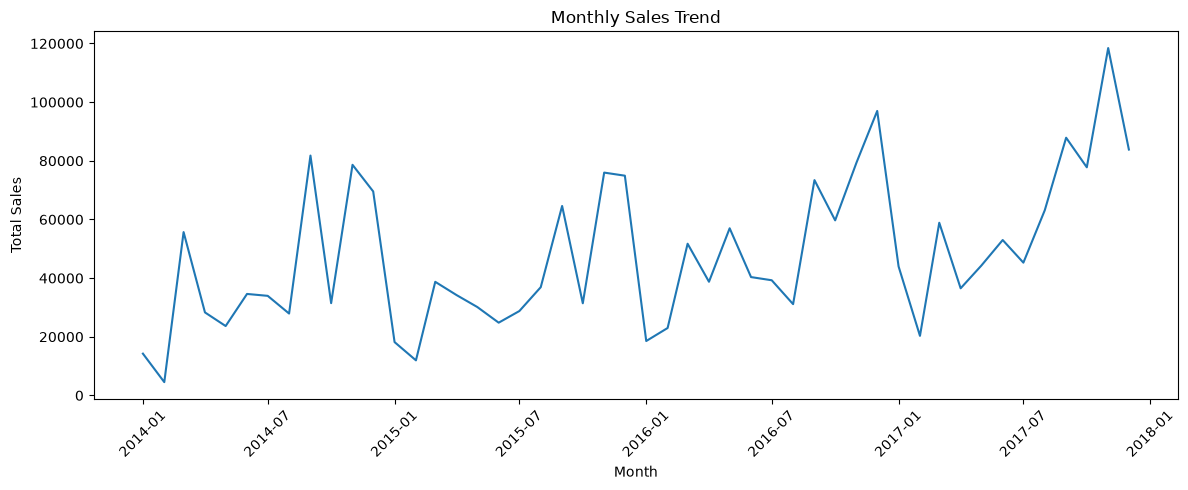

In [19]:
monthly_sale['Order Date'] = pd.to_datetime(
    monthly_sale['Order Date'].astype(str)
)

plt.figure(figsize=(12,5))

plt.plot(monthly_sale['Order Date'], monthly_sale['Sales'])

plt.title('Monthly Sales Trend')
plt.xlabel('Month')
plt.ylabel('Total Sales')
plt.xticks(rotation=45)

plt.tight_layout()
plt.savefig('monthly_sales_trend.png', dpi=300, bbox_inches='tight')
plt.show()

**Figure 2. Average sales by calendar month.**

November has the highest average sales, followed by December and September. February has the lowest average sales, indicating a recurring seasonal slowdown at the beginning of the year.

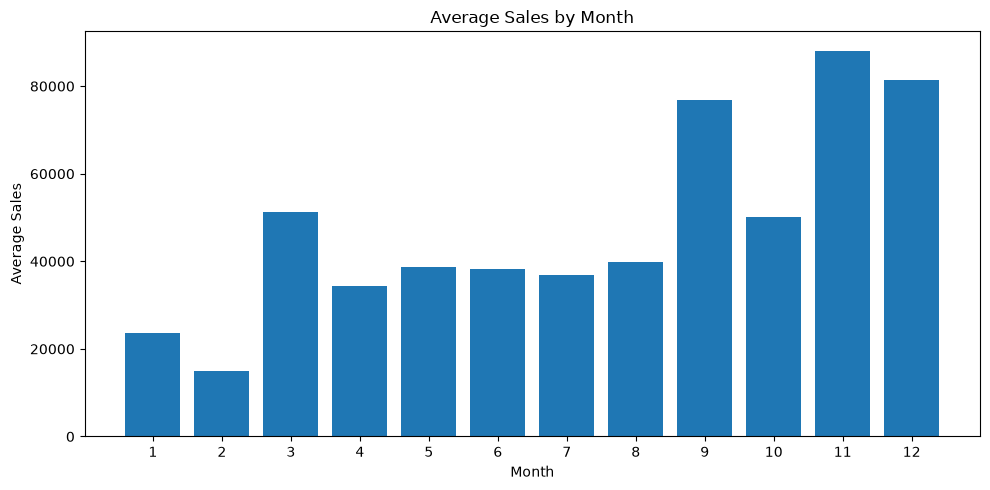

In [20]:
seasonality = monthly.groupby('Month')['Sales'].mean()

plt.figure(figsize=(10,5))

plt.bar(seasonality.index, seasonality.values)

plt.title('Average Sales by Month')
plt.xlabel('Month')
plt.ylabel('Average Sales')
plt.xticks(range(1,13))

plt.tight_layout()
plt.savefig('sales_seasonality.png', dpi=300, bbox_inches='tight')
plt.show()

##   Business Recommendations

### 1. Prepare for the year-end sales peak
November and December consistently show strong sales. The business should prepare inventory, staffing, and marketing resources ahead of this period.

### 2. Use targeted promotions during February
Since February is consistently weaker, targeted discounts, promotions, or campaigns could help stimulate demand during the seasonal slowdown.

### 3. Plan inventory around seasonal demand
Inventory and operational resources should be adjusted according to the seasonal pattern, with greater preparation before the September–December high-sales period.

## Mystery Question

### Which month looks like a problem but is actually normal?

February initially stands out because it repeatedly records relatively low sales.

However, February is not simply a one-time poor-performing month. Its low performance occurs consistently across multiple years, suggesting that the decline is part of a recurring seasonal pattern rather than an unexpected business problem.

###  Insight

**February appears to be a predictable seasonal low rather than a sudden business failure.**